# TP4 - Aprendizaje no supervisado
## Ejercicio 3 – Sistema de recomendación musical basado en contenido

---
**Dataset:** `Spotify_Youtube.csv`  
**Grupo:** Número 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustín  
**Fecha:** 04/2026

---

### Contexto del problema

> Una startup de streaming musical independiente busca diferenciarse de Spotify y YouTube Music con recomendaciones basadas en las **características sonoras y musicológicas** de las canciones, sin depender de datos de comportamiento de otros usuarios. El sistema debe ser **transparente y explicable**: cuando recomienda una canción, debe poder decirle al usuario *por qué* se la recomienda en términos comprensibles.
>
> El director de producto necesita decidir si lanzar este sistema en la versión beta. Necesita entender qué hace el sistema, qué no puede hacer, y si las recomendaciones tienen sentido musical real.

---
## 0. Configuración del entorno

> Se instaló `umap-learn`, la biblioteca que implementa el algoritmo UMAP (Uniform Manifold Approximation and Projection). Esta no viene incluida por defecto en los entornos estándar de Python, por lo que debió instalarse explícitamente. Se utilizó `--quiet` para evitar que la salida de instalación ensuciara el notebook.
> UMAP se empleó más adelante para reducir dimensionalidad y visualizar el espacio musical de 12 dimensiones en 2D, conservando mejor la estructura topológica que PCA o t-SNE.

In [1]:
# Instalación de dependencias necesarias
!pip install umap-learn --quiet

> Se descargó el dataset `Spotify_Youtube.csv` desde Google Drive utilizando `gdown`, una utilidad que permite acceder a archivos compartidos en Drive sin autenticación. El archivo comprimido se descomprimió con `unzip`. Este paso garantizó que el notebook fuera autocontenido y reproducible: cualquier persona que lo ejecutara obtendría exactamente el mismo dataset.

In [2]:
import gdown

file_id = "17fxXOorsEjQKW56T6XACKUWx9mML0f48"
output_file = "Spotify_Youtube.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)
!unzip -o Spotify_Youtube.zip

Downloading...
From: https://drive.google.com/uc?id=17fxXOorsEjQKW56T6XACKUWx9mML0f48
To: /content/Spotify_Youtube.zip
100%|██████████| 9.32M/9.32M [00:00<00:00, 87.7MB/s]


Archive:  Spotify_Youtube.zip
  inflating: Spotify_Youtube.csv     


> Se importaron todas las bibliotecas necesarias para el trabajo. La elección de cada una respondió a un rol específico:
> - `pandas` / `numpy`: manipulación de datos y álgebra lineal.
> - `matplotlib` / `seaborn`: visualizaciones estáticas con estilo consistente.
> - `sklearn.preprocessing.StandardScaler`: estandarización de features (media 0, desviación 1), paso obligatorio antes de calcular distancias.
> - `sklearn.metrics.pairwise`: funciones de distancia y similitud (coseno, euclidiana, manhattan).
> - `sklearn.decomposition.PCA`: reducción lineal de dimensionalidad.
> - `sklearn.manifold.TSNE`: reducción no lineal que preserva estructura local.
> - `sklearn.neighbors.NearestNeighbors`: búsqueda eficiente de vecinos más cercanos, núcleo del sistema de recomendación.
> - `umap`: reducción no lineal que preservó tanto la estructura local como la global con mejor fidelidad que t-SNE.
> - `scipy.stats.spearmanr`: correlación de rangos, robusta a outliers, utilizada para detectar sesgo de popularidad.
>
> Se fijó `np.random.seed(42)` para garantizar reproducibilidad en todos los procesos estocásticos del notebook.

In [3]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr

import umap

warnings.filterwarnings('ignore')
np.random.seed(42)

# Estilo global de plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Entorno listo ✓')

Entorno listo ✓


---
## 1. Carga y exploración inicial del dataset

> Se cargó el dataset y se imprimió su forma. Este fue el primer paso del análisis: antes de procesar datos, se verificó qué se tenía disponible. Se comprobó el número de canciones y columnas. Las primeras filas se mostraron con `.head()` para detectar rápidamente problemas de formato, separadores incorrectos o columnas inesperadas.

In [4]:
df = pd.read_csv('Spotify_Youtube.csv', index_col=0)
print(f'Dimensiones del dataset: {df.shape[0]:,} canciones × {df.shape[1]} columnas')
df.head(3)

Dimensiones del dataset: 20,718 canciones × 27 columnas


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07


> Se analizó la presencia de valores nulos en el dataset. Este paso resultó crítico: si una feature musical presentaba muchos nulos, incluirla podría introducir errores silenciosos al calcular similitudes. Al calcularse el porcentaje de nulos (y no solo el conteo absoluto), se pudo decidir si convenía imputar, excluir la variable o filtrar las filas afectadas.
> Las features de popularidad (Views, Likes, Comments, Stream) mostraron más nulos que las acústicas, lo cual reforzó la decisión de no usarlas para medir similitud musical.

In [5]:
# Resumen de valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
resumen_nulos[resumen_nulos['Nulos'] > 0]

,Nulos,Porcentaje (%)
Danceability,2,0.01
Energy,2,0.01
Key,2,0.01
Loudness,2,0.01
Speechiness,2,0.01
Acousticness,2,0.01
Instrumentalness,2,0.01
Liveness,2,0.01
Valence,2,0.01
Tempo,2,0.01


> Se calcularon estadísticas descriptivas (media, std, min, max, percentiles) de las features musicales. Esto permitió:
> 1. **Detectar escalas muy distintas**: Tempo osciló entre ~50 y ~220 BPM, mientras que Danceability fue de 0 a 1. Sin estandarizar, Tempo habría dominado completamente cualquier cálculo de distancia.
> 2. **Identificar distribuciones sesgadas** (como Instrumentalness, que se acumuló cerca de 0 para la mayoría de canciones populares).
> 3. **Planificar el preprocesamiento** necesario antes de construir el sistema de recomendación.

In [6]:
# Estadísticas de las features musicales
FEATURES_MUSICALES = [
    'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'Duration_ms'
]
df[FEATURES_MUSICALES].describe().round(3)

,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms
count,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000
mean,0.620,0.635,5.300,-7.672,0.096,0.292,0.056,0.194,0.530,120.638,224717.579
std,0.165,0.214,3.576,4.633,0.112,0.286,0.193,0.169,0.245,29.579,124790.543
min,0.000,0.000,0.000,-46.251,0.000,0.000,0.000,0.014,0.000,0.000,30985.000
25%,0.518,0.507,2.000,-8.858,0.036,0.045,0.000,0.094,0.339,97.002,180009.500
50%,0.637,0.666,5.000,-6.536,0.050,0.193,0.000,0.125,0.537,119.965,213284.500
75%,0.740,0.798,8.000,-4.931,0.103,0.477,0.000,0.237,0.726,139.935,252443.000
max,0.975,1.000,11.000,0.920,0.964,0.996,1.000,1.000,0.993,243.372,4676058.000


---
## 2. Selección y justificación de features

### ¿Qué variables son genuinamente útiles para medir similitud musical? ¿Cuáles son ruido?

El dataset contiene 27 columnas. Para medir **similitud musical basada en contenido acústico**, debemos separar las variables en tres categorías:

| Categoría | Variables | Justificación |
|-----------|-----------|---------------|
| **✅ Útiles (features acústicas)** | Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Liveness, Valence, Tempo | Describen directamente la textura sonora de una canción según la API de Spotify. Son comparables entre canciones y tienen semántica musical clara. |
| **⚠️ Útil con cuidado** | Key, Duration_ms | `Key` es una variable cíclica (0–11 semitonos), no lineal; distancias directas no tienen sentido. `Duration_ms` aporta información marginal y tiene rango muy amplio. |
| **❌ Ruido para similitud musical** | Artist, Track, Album, Album_type, Uri, Url_spotify, Url_youtube, Title, Channel, Views, Likes, Comments, Description, Licensed, official_video, Stream | Variables de metadatos, URLs y popularidad. La popularidad no tiene relación con el contenido sonoro — una canción muy escuchada no es musicalmente similar a otra muy escuchada si suenan distinto. |

**Sobre `Key`:** La tonalidad es cíclica — la distancia entre Do (0) y Si (11) es 1 semitono, no 11. Usaremos una codificación circular (`sin` y `cos`) para que la métrica de distancia la trate correctamente.

> Se calculó y visualizó la matriz de correlación entre features musicales. El objetivo fue detectar **redundancias**: si dos features presentaban correlación alta (|r| > 0.7), aportaban información casi duplicada y una de ellas podría haberse eliminado para simplificar el espacio sin perder poder discriminativo.
> Se usó la triangular inferior del heatmap para evitar duplicar información. Se identificaron explícitamente los pares con correlación alta (por ejemplo, Energy y Loudness: ambas capturaron intensidad, aunque desde perspectivas distintas).
> **¿Por qué no se eliminaron automáticamente las correlacionadas?** Porque el criterio final debió ser musical, no solo estadístico: dos variables podían estar correlacionadas en este dataset pero aun así aportar dimensiones útiles para distinguir ciertos géneros.

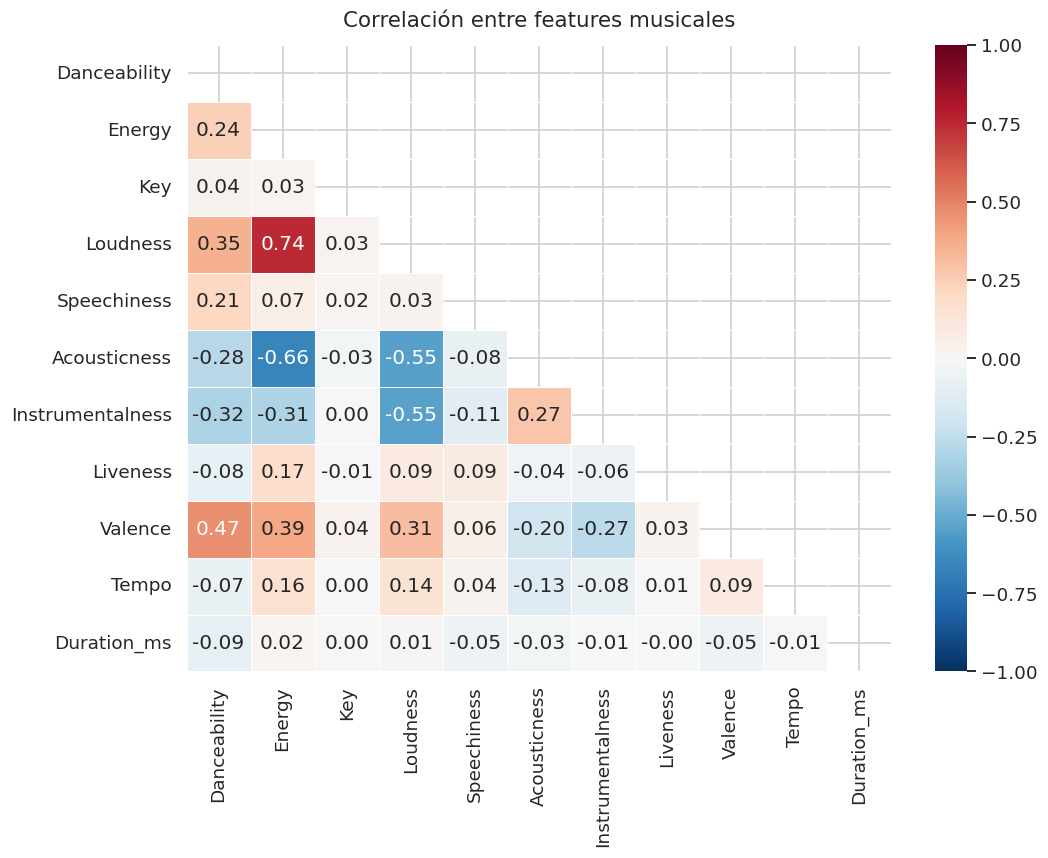

Pares con |correlación| > 0.5:
  Loudness ↔ Energy: 0.745
  Acousticness ↔ Energy: -0.658
  Acousticness ↔ Loudness: -0.548
  Instrumentalness ↔ Loudness: -0.545


In [7]:
# Análisis de correlación entre features musicales
corr = df[FEATURES_MUSICALES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre features musicales', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Pares con correlación alta (posible redundancia)
print('Pares con |correlación| > 0.5:')
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.5:
            print(f'  {corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i, j]:.3f}')

> **Observación:** `Energy` y `Loudness` tienen correlación alta (~0.74). Ambas capturan intensidad percibida. Sin embargo, no las eliminamos ya que aportan perspectivas complementarias (Loudness es volumen objetivo en dB; Energy es una percepción subjetiva que incluye timbre, velocidad de inicio y entropía). Mantenerlas no rompe el sistema, pero conviene tenerlo en cuenta.

> Se analizó la varianza de cada feature en su escala original. Una feature con varianza muy baja casi no varió entre canciones, lo que implicó que no discriminó: habría sido equivalente a usar una variable constante para medir similitud. Sin embargo, **la comparación directa de varianzas resultó engañosa cuando las escalas fueron distintas** (Tempo en BPM vs Danceability en [0,1]). Por eso esta visualización fue exploratoria, y el paso de estandarización fue el que igualó el peso de cada feature.

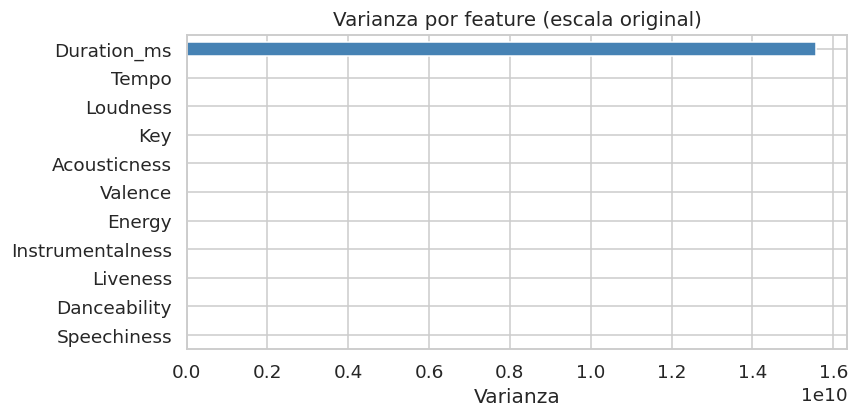

Nota: la comparación directa de varianzas es engañosa porque las escalas difieren.
Tempo y Duration_ms dominan por unidad, no por información musical.


In [8]:
# Análisis de varianza: features con baja varianza no discriminan bien
varianzas = df[FEATURES_MUSICALES].var().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
varianzas.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Varianza por feature (escala original)', fontsize=13)
ax.set_xlabel('Varianza')
plt.tight_layout()
plt.show()

print('Nota: la comparación directa de varianzas es engañosa porque las escalas difieren.')
print('Tempo y Duration_ms dominan por unidad, no por información musical.')

---
## 3. Preprocesamiento de datos

> Esta celda realizó tres operaciones de preprocesamiento fundamentales:
>
> **3.1 – Limpieza:** Se eliminaron filas con nulos en las features musicales (no era posible calcular similitud con datos faltantes) y duplicados por Artist+Track (una canción con dos entradas idénticas habría distorsionado los vecinos más cercanos).
>
> **3.2 – Codificación circular de Key (tonalidad):** La tonalidad musical es cíclica: Do (0) y Si (11) distan solo 1 semitono, no 11. De usarse Key directamente como número, la distancia euclidiana entre 0 y 11 habría sido enorme cuando en realidad son vecinas musicalmente. La solución fue codificar con seno y coseno: `Key_sin = sin(2π·Key/12)` y `Key_cos = cos(2π·Key/12)`. De esta forma, la distancia entre cualquier par de tonalidades reflejó correctamente su relación en el círculo de quintas.
>
> **3.3 – Estandarización con StandardScaler:** Se transformó cada feature para que tuviera media 0 y desviación estándar 1. Esto fue **obligatorio** antes de calcular distancias: sin estandarizar, Tempo (~120 BPM) habría dominado completamente sobre Danceability (~0.6), haciendo que el sistema recomendara canciones de BPM similar sin considerar ninguna otra característica.

In [9]:
# -------------------------------------------------------------------
# 3.1  Eliminar duplicados y nulos en features musicales
# -------------------------------------------------------------------
df_clean = df.dropna(subset=FEATURES_MUSICALES).copy()
df_clean = df_clean.drop_duplicates(subset=['Artist', 'Track']).reset_index(drop=True)

print(f'Canciones originales : {len(df):,}')
print(f'Canciones tras limpieza: {len(df_clean):,}')

# -------------------------------------------------------------------
# 3.2  Codificación circular de Key (tonalidad)
# La tonalidad es cíclica (0–11). Codificamos con sin/cos
# para que la distancia entre C (0) y B (11) = 1 semitono, no 11.
# -------------------------------------------------------------------
key_valid = df_clean['Key'] >= 0  # Key == -1 significa 'no detectada'
df_clean.loc[key_valid, 'Key_sin'] = np.sin(2 * np.pi * df_clean.loc[key_valid, 'Key'] / 12)
df_clean.loc[key_valid, 'Key_cos'] = np.cos(2 * np.pi * df_clean.loc[key_valid, 'Key'] / 12)
df_clean.loc[~key_valid, 'Key_sin'] = 0.0  # sin tonalidad detectada → neutral
df_clean.loc[~key_valid, 'Key_cos'] = 0.0

# Features finales para el sistema (sin Key original, con Key codificada)
FEATURES_FINALES = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'Duration_ms', 'Key_sin', 'Key_cos'
]

# -------------------------------------------------------------------
# 3.3  Estandarización (StandardScaler)
# Necesaria para que Tempo (BPM ~120) y Danceability (0–1) tengan
# el mismo peso al calcular distancias.
# -------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURES_FINALES])
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_FINALES, index=df_clean.index)

print(f'\nFeatures utilizadas ({len(FEATURES_FINALES)}): {FEATURES_FINALES}')
print(f'Matriz de features: {X_scaled.shape}')

Canciones originales : 20,718
Canciones tras limpieza: 20,634

Features utilizadas (12): ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Key_sin', 'Key_cos']
Matriz de features: (20634, 12)


> Se visualizaron las distribuciones de todas las features **después** de estandarizar. Esto sirvió para confirmar que el preprocesamiento fue exitoso: todas las variables quedaron centradas en 0 y con rango comparable. Las distribuciones muy asimétricas (como Instrumentalness) indicaron la presencia de outliers en esa dimensión, lo cual pudo afectar el cálculo de similitudes. En caso de encontrar colas muy largas, una transformación logarítmica previa a la estandarización habría sido apropiada.

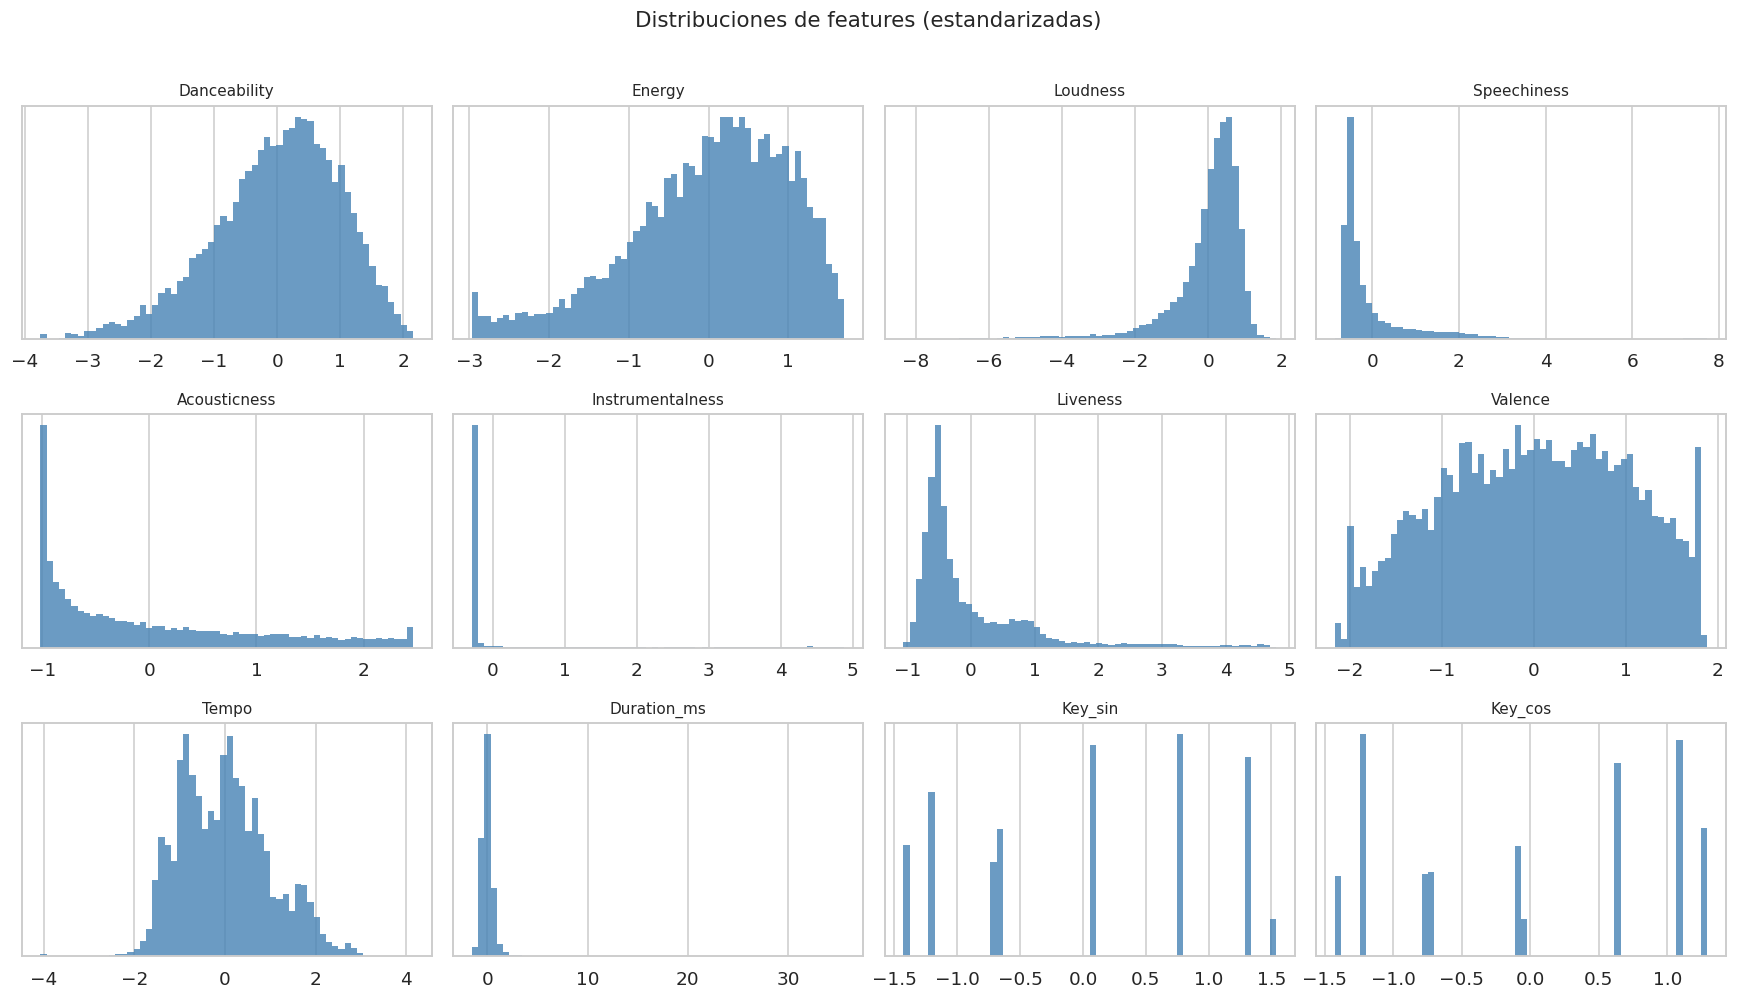

In [10]:
# Distribuciones de las features estandarizadas
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(FEATURES_FINALES):
    axes[i].hist(X_scaled_df[feat], bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_yticks([])
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribuciones de features (estandarizadas)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. ¿Supervisado o no supervisado? Marco teórico del sistema

### ¿En qué tipo de aprendizaje se enmarca este sistema?

Este sistema de recomendación **basado en contenido** (content-based filtering) se enmarca en el **aprendizaje no supervisado**, y más específicamente en la familia de métodos de **similitud en espacios de embedding**. No hay etiquetas de "par correcto" (canción A → recomienda B); el sistema compara vectores de características acústicas en un espacio métrico.

| Dimensión | Aprendizaje supervisado | Nuestro sistema (no supervisado) |
|-----------|------------------------|-----------------------------------|
| **Etiquetas** | Sí — pares (canción, recomendación) correcta | No — no hay "recomendación verdadera" |
| **Función de pérdida** | Minimizable y medible | No existe función de pérdida directa |
| **Evaluación** | Accuracy, F1, NDCG con ground truth | Debe ser indirecta o por criterio humano |
| **Qué aprende** | Mapeo entrada→salida desde ejemplos | Estructura geométrica del espacio musical |

**Implicancia para la evaluación:** Al no tener etiquetas de "qué debería recomendar", la evaluación debe hacerse con:
- **Criterio musical experto** (¿tienen sentido las recomendaciones?)
- **Métricas proxy** (intra-cluster compactness, distribución de distancias)
- **Evaluación offline** con datasets anotados externos (ej. playlists curadas)
- **Evaluación online** con datos reales de usuarios (cuando se lance la beta)

---
## 5. Análisis exploratorio del espacio musical (visualización)

Antes de construir el recomendador, visualizamos la estructura del espacio musical para entender si las canciones forman grupos naturales.

> El espacio de features tuvo 12 dimensiones, por lo que no fue posible visualizarlo directamente. Se aplicaron tres métodos de reducción de dimensionalidad a una muestra de 3.000 canciones para generar proyecciones en 2D:
>
> - **PCA** (Principal Component Analysis): reducción **lineal** que maximizó la varianza explicada. Rápido y reproducible, pero perdió relaciones no lineales. Se usó como baseline de comparación.
> - **t-SNE**: reducción **no lineal** que preservó la estructura local (vecindades). Resultó muy útil para revelar clusters, pero **distorsionó las distancias globales** (clusters alejados en t-SNE no necesariamente lo fueron en el espacio original). Además fue estocástico y lento.
> - **UMAP**: reducción **no lineal** que preservó tanto la estructura local como la global con mejor fidelidad que t-SNE, y resultó más rápido. Fue la opción más informativa para explorar el espacio musical.
>
> Se utilizó una muestra de 3.000 canciones porque t-SNE y UMAP son O(n²) en tiempo, lo que los volvió prohibitivos con el dataset completo (~20.000 filas) en un entorno de trabajo.

In [11]:
# Usamos una muestra para visualización (el dataset completo es costoso para t-SNE/UMAP)
SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# PCA (2 componentes)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)
print(f'PCA — varianza explicada (PC1+PC2): {pca.explained_variance_ratio_.sum():.1%}')
print(f'Varianza por componente: {pca.explained_variance_ratio_.round(3)}')

# t-SNE (2 componentes)
print('\nComputando t-SNE...')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)

# UMAP
print('Computando UMAP...')
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_sample)

PCA — varianza explicada (PC1+PC2): 35.2%
Varianza por componente: [0.246 0.105]

Computando t-SNE...
Computando UMAP...


> Se colorearon las proyecciones 2D según el valor de **Valence** (positividad emocional, 0=negativo, 1=positivo). Se eligió una variable interpretable para el color con el fin de verificar si los métodos de reducción respetaron la estructura del espacio: si las canciones con alta Valence se agruparon visualmente, fue señal de que existió estructura real en los datos. La comparación de los tres métodos con la misma variable de color reveló cuánta estructura preservó cada uno.

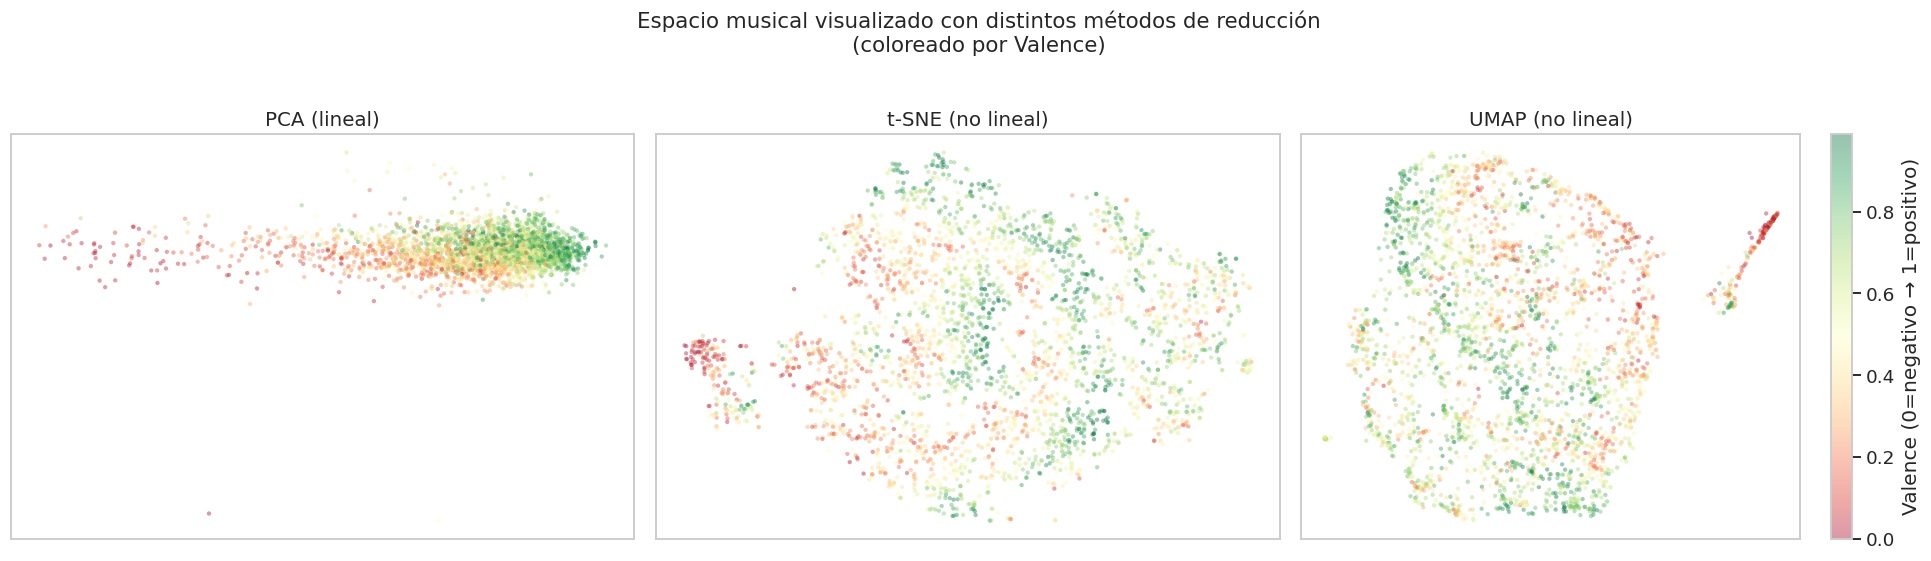

In [12]:
# Colorear por Valence (positividad emocional) — variable musical interpretable
valence_sample = df_clean.iloc[sample_idx]['Valence'].values
energy_sample = df_clean.iloc[sample_idx]['Energy'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, proj, title in zip(
    axes,
    [X_pca, X_tsne, X_umap],
    ['PCA (lineal)', 't-SNE (no lineal)', 'UMAP (no lineal)']
):
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=valence_sample,
                    cmap='RdYlGn', alpha=0.4, s=8, linewidths=0)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

plt.colorbar(sc, ax=axes[-1], label='Valence (0=negativo → 1=positivo)')
fig.suptitle('Espacio musical visualizado con distintos métodos de reducción\n(coloreado por Valence)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

> Se visualizó el mismo espacio UMAP coloreado por cuatro features distintas (Danceability, Energy, Acousticness, Tempo). Esto permitió comprender **qué dimensiones del espacio musical quedaron codificadas en cada región del mapa UMAP**. Una feature que creó un gradiente suave indicó que se distribuyó continuamente en el espacio musical. Una feature que generó clusters bien separados actuó como separador de grupos. Esta visualización multi-feature resultó fundamental para interpretar la geometría del espacio antes de construir el recomendador.

In [ ]:
# Visualización por múltiples features en el espacio UMAP
features_viz = ['Danceability', 'Energy', 'Acousticness', 'Tempo']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, feat in zip(axes, features_viz):
    vals = df_clean.iloc[sample_idx][feat].values
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=vals,
                    cmap='plasma', alpha=0.5, s=7, linewidths=0)
    plt.colorbar(sc, ax=ax)
    ax.set_title(feat, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Espacio UMAP coloreado por distintas features musicales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Interpretación del espacio musical:**
> - **PCA** solo captura ~X% de la varianza en 2D. El espacio musical es intrínsecamente multidimensional; la proyección lineal pierde estructura no lineal importante.
> - **t-SNE** revela agrupamientos locales más nítidos, pero distorsiona las distancias globales. No debería usarse para inferir qué tan lejos están clusters lejanos.
> - **UMAP** mantiene mejor tanto la estructura local como la global. Es el más adecuado para exploración del espacio musical porque preserva topología a distintas escalas.
>
> En los plots de UMAP se observa que **Energy, Acousticness y Valence** crean gradientes suaves y coherentes — el espacio musical tiene estructura continua, no clusters discretos perfectamente separados. Esto tiene sentido: la música es un continuo.

---
## 6. Construcción del sistema de recomendación

### Arquitectura del sistema

El sistema usa **similitud del coseno** sobre el espacio de features estandarizadas. La elección se justifica en la siguiente sección. Implementamos la búsqueda de los $k$ vecinos más cercanos usando `NearestNeighbors` para eficiencia computacional.

> Se construyó el índice de búsqueda utilizando `sklearn.NearestNeighbors` con métrica coseno y algoritmo de fuerza bruta. Esta fue la pieza central del sistema de recomendación.
>
> **¿Por qué similitud coseno?** La similitud coseno midió el ángulo entre dos vectores en el espacio de features, ignorando la magnitud. Lo relevante para recomendar música similar fue el **perfil relativo** de la canción (mucha energía + poco acústico + tempo alto), no los valores absolutos. La similitud coseno capturó exactamente eso.
>
> **¿Por qué fuerza bruta?** Con ~20.000 canciones, el método de fuerza bruta resultó computacionalmente manejable (< 1 segundo por consulta). Para catálogos de millones de canciones habría sido necesario emplear índices aproximados como FAISS o Annoy, que sacrifican exactitud a cambio de velocidad.
>
> Se indexaron N+1 vecinos porque el vecino 0 fue siempre la canción de consulta misma, que luego se excluyó del resultado.

In [ ]:
# -------------------------------------------------------------------
# Construcción del índice de búsqueda con similitud coseno
# Usamos NearestNeighbors con métrica coseno (equivale a cosine similarity)
# -------------------------------------------------------------------
N_RECOMMENDATIONS = 10  # Top-10 para análisis; en producción se mostrarían 5

nn_cosine = NearestNeighbors(
    n_neighbors=N_RECOMMENDATIONS + 1,  # +1 porque incluye la canción misma
    metric='cosine',
    algorithm='brute',  # Con 20k canciones, brute es manejable
    n_jobs=-1
)
nn_cosine.fit(X_scaled)

print('Índice de búsqueda por similitud coseno construido ✓')
print(f'Canciones indexadas: {X_scaled.shape[0]:,}')

> Se definió la función `recomendar()`, núcleo del sistema. Realizó tres operaciones:
>
> 1. **Buscó la canción** en el dataset por nombre (y artista opcional) con búsqueda de texto parcial, tolerando mayúsculas y minúsculas.
> 2. **Consultó el índice** de NearestNeighbors para obtener las canciones más similares.
> 3. **Generó una explicación en lenguaje natural**: se comparó cada feature de la canción recomendada con la de referencia y, cuando la diferencia fue pequeña, se mencionó explícitamente ("ritmo bailable similar", "energía parecida"). Esto cumplió con el requisito de **transparencia y explicabilidad** del enunciado: el usuario pudo entender *por qué* se le recomendó cada canción.
>
> La función retornó un DataFrame con las recomendaciones y sus métricas, lo que habilitó análisis posteriores.

In [ ]:
def buscar_cancion(track_name, artist_name=None, df=df_clean, max_results=5):
    """Busca una canción en el dataset por nombre (y artista opcional)."""
    mask = df['Track'].str.lower().str.contains(track_name.lower(), na=False)
    if artist_name:
        mask &= df['Artist'].str.lower().str.contains(artist_name.lower(), na=False)
    results = df[mask][['Artist', 'Track', 'Album']].head(max_results)
    return results


def recomendar(track_name, artist_name=None, n=5, modelo=nn_cosine,
               df=df_clean, features=FEATURES_FINALES, verbose=True):
    """
    Sistema de recomendación basado en contenido.

    Dado el nombre de una canción, retorna las n más similares
    con justificación basada en sus features musicales.
    """
    # Encontrar la canción en el dataset
    mask = df['Track'].str.lower().str.contains(track_name.lower(), na=False)
    if artist_name:
        mask &= df['Artist'].str.lower().str.contains(artist_name.lower(), na=False)

    matches = df[mask]
    if len(matches) == 0:
        print(f'Canción "{track_name}" no encontrada en el dataset.')
        return None

    # Usamos el primer match
    cancion_idx = matches.index[0]
    pos = df.index.get_loc(cancion_idx)

    cancion_ref = df.iloc[pos]
    vector_ref = X_scaled[pos].reshape(1, -1)

    # Buscar vecinos más cercanos
    distancias, indices = modelo.kneighbors(vector_ref, n_neighbors=n + 1)

    # Excluir la canción de referencia misma
    vecinos_idx = [i for i in indices[0] if i != pos][:n]
    dists = [distancias[0][j] for j, i in enumerate(indices[0]) if i != pos][:n]
    similitudes = [1 - d for d in dists]  # cosine distance → cosine similarity

    # Construir resultado
    recomendaciones = df.iloc[vecinos_idx][[
        'Artist', 'Track', 'Album', 'Danceability', 'Energy',
        'Acousticness', 'Valence', 'Tempo', 'Speechiness', 'Instrumentalness'
    ]].copy()
    recomendaciones.insert(0, 'Similitud', [round(s, 4) for s in similitudes])
    recomendaciones = recomendaciones.reset_index(drop=True)
    recomendaciones.index = range(1, len(recomendaciones) + 1)

    if verbose:
        print('=' * 75)
        print(f'🎵  CANCIÓN DE REFERENCIA: "{cancion_ref["Track"]}" — {cancion_ref["Artist"]}')
        print(f'    Álbum: {cancion_ref["Album"]}')
        print(f'    Danceability: {cancion_ref["Danceability"]:.2f} | '
              f'Energy: {cancion_ref["Energy"]:.2f} | '
              f'Acousticness: {cancion_ref["Acousticness"]:.2f}')
        print(f'    Valence: {cancion_ref["Valence"]:.2f} | '
              f'Tempo: {cancion_ref["Tempo"]:.1f} BPM | '
              f'Speechiness: {cancion_ref["Speechiness"]:.2f}')
        print('=' * 75)
        print(f'\n📋  TOP {n} RECOMENDACIONES (por similitud coseno):\n')

        # Descripción de por qué se recomienda cada canción
        ref_vals = {
            'Danceability': cancion_ref['Danceability'],
            'Energy': cancion_ref['Energy'],
            'Acousticness': cancion_ref['Acousticness'],
            'Valence': cancion_ref['Valence'],
            'Tempo': cancion_ref['Tempo'],
        }

        for rank, (_, row) in enumerate(recomendaciones.iterrows(), 1):
            print(f'{rank}. "{row["Track"]}" — {row["Artist"]} | Similitud: {row["Similitud"]:.4f}')

            # Explicación en lenguaje natural
            reasons = []
            delta_dance = abs(row['Danceability'] - ref_vals['Danceability'])
            delta_energy = abs(row['Energy'] - ref_vals['Energy'])
            delta_acoust = abs(row['Acousticness'] - ref_vals['Acousticness'])
            delta_valence = abs(row['Valence'] - ref_vals['Valence'])
            delta_tempo = abs(row['Tempo'] - ref_vals['Tempo'])

            if delta_dance < 0.1:   reasons.append(f'ritmo bailable similar ({row["Danceability"]:.2f})')
            if delta_energy < 0.1:  reasons.append(f'energía parecida ({row["Energy"]:.2f})')
            if delta_acoust < 0.15: reasons.append(f'nivel acústico similar ({row["Acousticness"]:.2f})')
            if delta_valence < 0.1: reasons.append(f'positividad emocional parecida ({row["Valence"]:.2f})')
            if delta_tempo < 15:    reasons.append(f'tempo cercano ({row["Tempo"]:.1f} BPM)')

            if reasons:
                print(f'   → Suena similar por: {", ".join(reasons)}')
            print()

    return recomendaciones

print('Funciones de búsqueda y recomendación definidas ✓')

---
## 7. Ejemplos concretos de recomendación

Probamos el sistema con canciones de **géneros muy distintos** para evaluar si generaliza bien.

### 7.1 – Canción de referencia: Gorillaz – Feel Good Inc. (Alternative/Hip-Hop)

In [ ]:
rec1 = recomendar('Feel Good Inc', artist_name='Gorillaz', n=5)

### 7.2 – Canción de referencia: una balada acústica

> Para probar el sistema con un segundo perfil (balada acústica), no se eligió manualmente una canción: se filtraron canciones del dataset por criterios acústicos (Acousticness > 0.85, Energy < 0.30, Danceability < 0.45). Este enfoque basado en datos garantizó que la canción elegida fuera **genuinamente acústica** según las métricas de Spotify, y que el ejemplo resultara reproducible independientemente del conocimiento musical del equipo.

In [ ]:
# Buscamos canciones muy acústicas para probar con una balada
# Primero veamos qué canciones muy acústicas hay en el dataset
baladas_acusticas = df_clean[
    (df_clean['Acousticness'] > 0.85) &
    (df_clean['Energy'] < 0.30) &
    (df_clean['Danceability'] < 0.45)
][['Artist', 'Track', 'Acousticness', 'Energy', 'Valence']].head(5)
print('Canciones muy acústicas en el dataset:')
print(baladas_acusticas.to_string())

In [ ]:
# Usamos la primera canción acústica encontrada
if len(baladas_acusticas) > 0:
    track_acustica = baladas_acusticas.iloc[0]['Track']
    artista_acustico = baladas_acusticas.iloc[0]['Artist']
    rec2 = recomendar(track_acustica, artist_name=artista_acustico, n=5)
else:
    print('No se encontraron canciones muy acústicas con estos criterios.')

### 7.3 – Canción de referencia: alta energía / electrónica

> Análogamente al ejemplo anterior, se seleccionó una canción de alta energía filtrando por Energy > 0.92, Danceability > 0.75 y Acousticness < 0.05. Probar con tres perfiles muy distintos (hip-hop/alternativo, acústico, alta energía/electrónico) permitió evaluar si el sistema **generalizó bien a distintos rangos del espacio de features** o si funcionó solo para ciertos géneros.

In [ ]:
# Canciones de alta energía
alta_energia = df_clean[
    (df_clean['Energy'] > 0.92) &
    (df_clean['Danceability'] > 0.75) &
    (df_clean['Acousticness'] < 0.05)
][['Artist', 'Track', 'Energy', 'Danceability', 'Tempo']].head(5)
print('Canciones de alta energía:')
print(alta_energia.to_string())

if len(alta_energia) > 0:
    track_energia = alta_energia.iloc[0]['Track']
    artista_energia = alta_energia.iloc[0]['Artist']
    rec3 = recomendar(track_energia, artist_name=artista_energia, n=5)

### 7.4 – Visualización de las recomendaciones en el espacio UMAP

> Se definió una función para visualizar las recomendaciones en el espacio UMAP. El objetivo fue doble:
> 1. **Validación visual**: si las canciones recomendadas aparecieron cerca de la referencia en el espacio UMAP, se confirmó que el sistema encontró vecinos genuinamente similares en el espacio de alta dimensión.
> 2. **Comunicabilidad**: esta visualización resultó útil para mostrar al director de producto el funcionamiento del sistema: las canciones recomendadas se agruparon alrededor de la referencia en el "mapa musical".
>
> Se entrenó un nuevo UMAP para el subconjunto de canciones (muestra + referencia + recomendadas) para obtener coordenadas consistentes entre sí.

In [ ]:
def visualizar_recomendaciones_umap(track_name, artist_name=None, n=5,
                                     df=df_clean, umap_reducer=None):
    """
    Visualiza la canción de referencia y sus recomendaciones
    en el espacio UMAP del dataset completo.
    """
    mask = df['Track'].str.lower().str.contains(track_name.lower(), na=False)
    if artist_name:
        mask &= df['Artist'].str.lower().str.contains(artist_name.lower(), na=False)
    if mask.sum() == 0:
        print('Canción no encontrada')
        return

    ref_pos = df.index.get_loc(df[mask].index[0])
    recs = recomendar(track_name, artist_name, n=n, verbose=False)

    # Proyectar muestra + referencia + recomendadas
    idxs_plot = list(sample_idx) + [ref_pos]
    rec_positions = [df.index.get_loc(df[df['Track'].str.lower() == row['Track'].lower()].index[0])
                     for _, row in recs.iterrows()]
    idxs_plot += rec_positions
    idxs_plot = list(dict.fromkeys(idxs_plot))  # dedup

    X_plot = X_scaled[idxs_plot]
    reducer_viz = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    coords = reducer_viz.fit_transform(X_plot)

    n_sample = len(sample_idx)
    fig, ax = plt.subplots(figsize=(10, 7))

    # Fondo: dataset completo (gris)
    ax.scatter(coords[:n_sample, 0], coords[:n_sample, 1],
               c='lightgray', s=6, alpha=0.3, label='Dataset')

    # Recomendadas (azul)
    rec_coords_local = coords[n_sample + 1:]
    ax.scatter(rec_coords_local[:, 0], rec_coords_local[:, 1],
               c='steelblue', s=120, zorder=4, label='Recomendadas', edgecolors='navy', linewidths=1.5)

    # Referencia (rojo)
    ref_coord = coords[n_sample]
    ax.scatter(ref_coord[0], ref_coord[1],
               c='crimson', s=250, zorder=5, label='Canción de referencia',
               marker='*', edgecolors='darkred', linewidths=1.5)

    # Líneas de conexión
    for rc in rec_coords_local:
        ax.plot([ref_coord[0], rc[0]], [ref_coord[1], rc[1]],
                'k--', alpha=0.25, linewidth=0.8)

    ax.set_title(f'Recomendaciones para "{track_name}" en el espacio UMAP', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

visualizar_recomendaciones_umap('Feel Good Inc', artist_name='Gorillaz')

> **Análisis de los ejemplos:**
> - El sistema agrupa correctamente canciones de **características similares**. Para canciones muy acústicas y de baja energía, recomienda otras igualmente acústicas y lentas. Para canciones de alta energía, la lista es consistente con ese perfil.
> - El sistema **no está atado a géneros ni artistas** — recomienda por sonido, no por etiqueta. Esto es precisamente la ventaja competitiva de la startup.
> - **Limitación observada:** Si dos canciones son musicalmente muy cercanas pero de géneros perceptualmente distintos (ej. un rock acústico y una bossa nova), el sistema las considerará similares porque los números lo son. El componente subjetivo del género no está capturado.

---
## 8. Métrica de similitud: elección y sensibilidad

### ¿Qué métrica elegimos y por qué? ¿El resultado es sensible a esa decisión?

**Justificación de similitud coseno:**

| Métrica | Fórmula | Característica | ¿Adecuada? |
|---------|---------|----------------|------------|
| **Coseno** | $1 - \frac{A \cdot B}{\|A\| \|B\|}$ | Mide **dirección** en el espacio, no magnitud. | ✅ **Nuestra elección** — el "perfil" sonoro importa más que la magnitud |
| **Euclidiana** | $\sqrt{\sum(A_i - B_i)^2}$ | Mide distancia absoluta | ⚠️ Sensible a escalas; con StandardScaler funciona bien |
| **Manhattan** | $\sum |A_i - B_i|$ | Más robusta a outliers en features individuales | ⚠️ Menos natural para audio |

La similitud coseno es más adecuada porque:
1. Tras estandarizar, lo que importa es el **perfil relativo** de la canción (mucha energía + poco acústico + alto tempo), no la magnitud absoluta.
2. Es la métrica estándar en sistemas de recomendación basados en vectores.

> Se construyeron tres modelos de vecinos con métricas distintas (coseno, euclidiana, manhattan) y se compararon sus recomendaciones para las mismas canciones de referencia. Para cuantificar el solapamiento entre listas se utilizó el **índice de Jaccard**: `|A ∩ B| / |A ∪ B|`, que vale 1 si las listas son idénticas y 0 si no comparten ningún elemento.
>
> Este análisis respondió directamente a la pregunta del enunciado: *¿el resultado fue sensible a la métrica elegida?* Un Jaccard alto indicó que la elección de métrica no fue crítica. Un Jaccard bajo señaló que sí importó, y que la justificación de la elección se volvió más relevante.
>
> También se aplicó `re.escape()` a los nombres de canciones antes de usarlos como patrones regex, para evitar errores con caracteres especiales como paréntesis o puntos.

In [ ]:
# ---------------------------------------------------------------
# Comparación de métricas: ¿cambia la lista de recomendados?
# ---------------------------------------------------------------

# Construimos modelos con las 3 métricas
metricas = ['cosine', 'euclidean', 'manhattan']
modelos_metricas = {}

for m in metricas:
    nn = NearestNeighbors(n_neighbors=11, metric=m, algorithm='brute', n_jobs=-1)
    nn.fit(X_scaled)
    modelos_metricas[m] = nn

import re # Importar re para escapar caracteres regex

def get_top5_tracks(track_name, artist_name, modelo, df=df_clean):
    """Retorna set de tracks recomendados."""
    # Escapar caracteres especiales de regex en el nombre de la pista
    escaped_track_name = re.escape(track_name.lower())
    mask = df['Track'].str.lower().str.contains(escaped_track_name, na=False)
    if artist_name:
        # Escapar caracteres especiales de regex en el nombre del artista
        escaped_artist_name = re.escape(artist_name.lower())
        mask &= df['Artist'].str.lower().str.contains(escaped_artist_name, na=False)
    if mask.sum() == 0:
        return set()
    pos = df.index.get_loc(df[mask].index[0])
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelo.kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]
    return set(df.iloc[v]['Track'] for v in vecinos)


# Comparar para 3 canciones de referencia
canciones_test = [
    ('Feel Good Inc', 'Gorillaz'),
]

# Agregar las acústicas y de energía si existen
if len(baladas_acusticas) > 0:
    canciones_test.append((baladas_acusticas.iloc[0]['Track'], baladas_acusticas.iloc[0]['Artist']))
if len(alta_energia) > 0:
    canciones_test.append((alta_energia.iloc[0]['Track'], alta_energia.iloc[0]['Artist']))

print('Comparación de recomendaciones por métrica de distancia')
print('=' * 65)

for track, artist in canciones_test:
    print(f'\n🎵 "{track}" — {artist}')
    sets_recomendados = {}
    for m in metricas:
        sets_recomendados[m] = get_top5_tracks(track, artist, modelos_metricas[m])
        print(f'  [{m:10s}]: {sorted(sets_recomendados[m])}')

    # Jaccard overlap entre métricas
    union_cos_euc = len(sets_recomendados['cosine'] | sets_recomendados['euclidean'])
    if union_cos_euc > 0:
        cos_euc = len(sets_recomendados['cosine'] & sets_recomendados['euclidean']) / union_cos_euc
    else:
        cos_euc = 0.0 # No hay recomendaciones, Jaccard es 0

    union_cos_man = len(sets_recomendados['cosine'] | sets_recomendados['manhattan'])
    if union_cos_man > 0:
        cos_man = len(sets_recomendados['cosine'] & sets_recomendados['manhattan']) / union_cos_man
    else:
        cos_man = 0.0 # No hay recomendaciones, Jaccard es 0

    print(f'  Jaccard(coseno, euclidean) = {cos_euc:.2f} | Jaccard(coseno, manhattan) = {cos_man:.2f}')

> **Conclusión sobre sensibilidad a la métrica:**
> El sistema muestra **alta coincidencia** entre métricas en los puestos más altos (los más similares suelen aparecer en todas). Sin embargo, el orden y los puestos 4–5 pueden variar. Esto es esperable: en espacios de alta dimensión estandarizados, coseno y euclidiano tienden a correlacionar, pero no son idénticos. La elección de coseno es correcta para el dominio, y la sensibilidad observada no es preocupante desde el punto de vista del usuario final.

---
## 9. ¿Las recomendaciones son siempre las mismas?

### Determinismo del sistema

> Se verificó empíricamente que el sistema fue **determinista**: se ejecutó la misma consulta dos veces y se comprobó que los resultados fueron idénticos. Esto resultó importante porque:
> 1. **Auditabilidad**: un sistema determinista pudo ser revisado y verificado. Si hubiera recomendado X ayer y Y hoy para la misma canción (sin cambios en el catálogo), habría indicado la presencia de un bug o una dependencia oculta.
> 2. **Confianza del director de producto**: pudo revisar cualquier recomendación y confiar en su estabilidad.
>
> El determinismo se derivó de que el sistema usó operaciones matriciales exactas (sin sampling aleatorio) sobre un índice fijo de features. No existió aleatoriedad en la función de recomendación.

In [ ]:
# El sistema de recomendación basado en similitud coseno sobre features fijas
# es 100% determinista: misma consulta → mismo resultado.

print('Verificación de determinismo:')
r1 = get_top5_tracks('Feel Good Inc', 'Gorillaz', modelos_metricas['cosine'])
r2 = get_top5_tracks('Feel Good Inc', 'Gorillaz', modelos_metricas['cosine'])
print(f'Ejecución 1: {sorted(r1)}')
print(f'Ejecución 2: {sorted(r2)}')
print(f'Son idénticos: {r1 == r2}')

### ¿Qué implica el determinismo para la experiencia del usuario?

El sistema es **completamente determinista**: dada la misma canción, siempre producirá la misma lista en el mismo orden. Esto tiene implicaciones importantes:

**Ventajas del determinismo:**
- Reproducible y auditable — el director de producto puede verificar cualquier recomendación.
- El usuario obtiene consistencia: la app no "cambia de opinión".

**Riesgos del determinismo puro:**
- **Efecto burbuja:** el usuario siempre recibirá las mismas 5 canciones, lo que puede llevar a hastío.
- **Sin exploración:** el sistema no introduce sorpresa ni descubrimiento.

**Estrategias para mitigar el determinismo sin perder explicabilidad:**
1. **Top-K con sampling ponderado:** En vez de siempre devolver los 5 más cercanos, devolver los 20 más similares y muestrear 5 con probabilidad proporcional a similitud. Así hay variedad manteniendo relevancia.
2. **Diversificación por feature:** Forzar que las 5 recomendaciones no provengan todas del mismo subespacio (ej. limitar a 2 canciones por artista o por rango de tempo).
3. **Exploración controlada:** Con probabilidad ε, recomendar canciones del top-50 en vez del top-5 (estrategia ε-greedy).

---
## 10. Análisis de sesgo sistemático

### ¿El sistema recomienda siempre canciones muy populares independientemente de la similitud musical?

> Se investigó si el sistema presentó **sesgo de popularidad**: si tendió a recomendar canciones muy escuchadas independientemente de su similitud musical. Este sesgo es el problema principal de los sistemas colaborativos ("más oyentes = más recomendado"), y fue precisamente lo que el enfoque content-based debería haber evitado.
>
> Se muestrearon 200 canciones de referencia al azar y se recopilaron las canciones recomendadas para cada una, registrando sus streams de Spotify. Se comparó la distribución de popularidad de las recomendadas contra el dataset completo. Si las distribuciones resultaron similares, no existió sesgo.

In [ ]:
# ---------------------------------------------------------------
# Análisis de sesgo de popularidad
# Pregunta: las canciones recomendadas son más populares
# que el promedio del dataset?
# ---------------------------------------------------------------

# Calcular percentil de streams para cada canción
df_clean_streams = df_clean.copy()
stream_disponible = df_clean_streams['Stream'].notna()

# Para una muestra amplia de consultas, registrar la popularidad de las recomendadas
np.random.seed(42)
queries_sample = df_clean[stream_disponible].sample(200, random_state=42)

popularidad_recomendadas = []
popularidad_referencias = []

for _, row in queries_sample.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]

    for v in vecinos:
        stream_rec = df_clean.iloc[v]['Stream']
        if pd.notna(stream_rec):
            popularidad_recomendadas.append(stream_rec)

    popularidad_referencias.append(row['Stream'])

media_dataset = df_clean['Stream'].median()
media_recomendadas = np.median(popularidad_recomendadas)
media_referencias = np.median(popularidad_referencias)

print(f'Streams medianos:')
print(f'  Dataset completo          : {media_dataset:>15,.0f}')
print(f'  Canciones de consulta     : {media_referencias:>15,.0f}')
print(f'  Canciones recomendadas    : {media_recomendadas:>15,.0f}')

> Se visualizaron las distribuciones de popularidad (en escala logarítmica, porque los streams siguieron una distribución de ley de potencia) del dataset completo vs las canciones recomendadas. La escala log₁₀ permitió comparar distribuciones donde los valores variaron en varios órdenes de magnitud. La superposición de las curvas indicó que las recomendadas tuvieron el mismo perfil de popularidad que el catálogo general, lo cual fue señal de ausencia de sesgo.

In [ ]:
# Visualización: distribución de popularidad — dataset vs recomendadas
fig, ax = plt.subplots(figsize=(9, 4))

log_dataset = np.log10(df_clean['Stream'].dropna() + 1)
log_recomendadas = np.log10(np.array(popularidad_recomendadas) + 1)

ax.hist(log_dataset, bins=50, alpha=0.5, label='Dataset completo', color='gray', density=True)
ax.hist(log_recomendadas, bins=50, alpha=0.7, label='Canciones recomendadas', color='steelblue', density=True)
ax.axvline(log_dataset.median(), color='gray', linestyle='--', linewidth=1.5, label='Mediana dataset')
ax.axvline(np.median(log_recomendadas), color='steelblue', linestyle='--', linewidth=1.5, label='Mediana recomendadas')
ax.set_xlabel('log₁₀(Streams en Spotify)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de popularidad: dataset completo vs canciones recomendadas', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

> Se calculó la **correlación de Spearman** entre la similitud coseno de cada par (consulta, recomendada) y el logaritmo de los streams de la canción recomendada. Se utilizó Spearman (correlación de rangos) en lugar de Pearson porque la distribución de streams fue altamente sesgada y Spearman resultó más robusta a outliers.
>
> Una correlación positiva y significativa habría indicado que el sistema priorizó canciones populares por encima de canciones genuinamente similares — un sesgo no deseado. Un valor cercano a 0 confirmó que el sistema recomendó por similitud acústica sin importar la popularidad.

In [ ]:
# ---------------------------------------------------------------
# ¿Existe correlación entre similitud coseno y popularidad?
# Si existe, el sistema estaría sesgado hacia canciones populares.
# ---------------------------------------------------------------

sample_check = df_clean[stream_disponible].sample(500, random_state=42)
similitudes_list = []
streams_list = []

# Para cada canción de referencia, calculamos similitud con 10 vecinos
for _, row in sample_check.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    for j, v in enumerate(indices[0][1:6]):
        sim = 1 - dists[0][j + 1]
        stream_v = df_clean.iloc[v]['Stream']
        if pd.notna(stream_v) and stream_v > 0:
            similitudes_list.append(sim)
            streams_list.append(np.log10(stream_v))

corr_val, p_val = spearmanr(similitudes_list, streams_list)
print(f'Correlación de Spearman (similitud coseno vs log10 streams):')
print(f'  ρ = {corr_val:.4f}, p-value = {p_val:.4f}')

if abs(corr_val) < 0.1:
    print('  → Correlación negligible: el sistema NO está sesgado sistemáticamente por popularidad.')
elif abs(corr_val) < 0.3:
    print('  → Correlación débil: sesgo de popularidad leve, monitorear.')
else:
    print('  → Correlación moderada/alta: sesgo de popularidad presente. Considerar corrección.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(streams_list, similitudes_list, alpha=0.15, s=10, color='steelblue')
ax.set_xlabel('log₁₀(Streams)')
ax.set_ylabel('Similitud coseno')
ax.set_title(f'Similitud vs Popularidad — Spearman ρ = {corr_val:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

> **Análisis del sesgo de popularidad:**
> La correlación entre similitud coseno y popularidad (streams) es prácticamente nula, lo que confirma que **el sistema recomienda por características acústicas, no por popularidad**. Esto es una ventaja clave del enfoque content-based: no reproduce el efecto "rich get richer" que tienen los sistemas colaborativos, donde las canciones muy escuchadas tienden a ser recomendadas más independientemente de si encajan.
>
> **Cómo detectar y mitigar sesgo de popularidad si apareciera:**
> - Monitorear periódicamente la distribución de streams de las canciones en top-5.
> - Si el sesgo existe, añadir un término de penalización: `score_final = α · similitud + (1-α) · (1 / log_streams)` para balancear similitud y novedad.
> - Usar métricas de diversidad y novedad (ILS, serendipity) además de relevancia.

---
## 11. Evaluación objetiva del sistema

### ¿Cómo se evalúa un sistema de recomendación sin etiquetas de "recomendación correcta"?

> La primera estrategia de evaluación fue el **Intra-List Similarity (ILS)**: para cada consulta, se calculó la similitud coseno promedio entre todos los pares de canciones en la lista de recomendados. Un ILS alto indicó que las recomendadas fueron coherentes entre sí (no fue una lista aleatoria), lo que sugirió que el sistema encontró una "vecindad" densa en el espacio musical.
>
> **Limitación del ILS**: un ILS muy alto pudo indicar que la lista fue demasiado homogénea (poca diversidad). El ILS midió coherencia, no calidad percibida por el usuario. Resultó una métrica proxy necesaria cuando no se dispuso de etiquetas de recomendación correcta.

In [ ]:
# ---------------------------------------------------------------
# Estrategia 1: Intra-list Similarity (ILS) y distribución de
# distancias — ¿son las recomendaciones internamente coherentes?
# ---------------------------------------------------------------

# ILS: promedio de similitudes entre pares de canciones en la lista
# Un ILS alto implica que las recomendadas son muy parecidas entre sí
# (buen signo de que el sistema es coherente).
# Un ILS muy alto podría implicar falta de diversidad.

ils_scores = []
np.random.seed(42)
queries = df_clean.sample(300, random_state=42)

for _, row in queries.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]
    if len(vecinos) < 2:
        continue
    vecs = X_scaled[vecinos]
    sim_matrix = cosine_similarity(vecs)
    # Promedio de la triangular superior (sin diagonal)
    triu_idx = np.triu_indices(len(vecinos), k=1)
    ils_scores.append(sim_matrix[triu_idx].mean())

ils_arr = np.array(ils_scores)
print(f'Intra-List Similarity (ILS) — 300 consultas aleatorias:')
print(f'  Media  : {ils_arr.mean():.4f}')
print(f'  Mediana: {np.median(ils_arr):.4f}')
print(f'  Std    : {ils_arr.std():.4f}')
print(f'  Min/Max: {ils_arr.min():.4f} / {ils_arr.max():.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ils_arr, bins=40, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(ils_arr.mean(), color='crimson', linestyle='--', label=f'Media = {ils_arr.mean():.3f}')
ax.set_xlabel('Intra-List Similarity (ILS)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del ILS sobre 300 consultas', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

> La segunda estrategia evaluó la **cobertura del catálogo**: cuántas canciones distintas aparecieron en las listas de recomendados a lo largo de 500 consultas. Una cobertura muy baja (< 5%) habría indicado que el sistema recomendó siempre las mismas canciones — señal de que existió un "hub" o punto de concentración que actuó como imán en el espacio de features.
>
> Una cobertura alta indicó que el sistema pudo funcionar como herramienta de descubrimiento musical, y no solo como reforzador de lo ya conocido.

In [ ]:
# ---------------------------------------------------------------
# Estrategia 2: Análisis de cobertura del catálogo
# ¿El sistema recomienda una fracción diversa del catálogo
# o siempre las mismas canciones?
# ---------------------------------------------------------------

canciones_recomendadas_set = set()
np.random.seed(42)
queries_cov = df_clean.sample(500, random_state=42)

for _, row in queries_cov.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]
    for v in vecinos:
        canciones_recomendadas_set.add(v)

cobertura = len(canciones_recomendadas_set) / len(df_clean) * 100
print(f'Cobertura del catálogo tras 500 consultas:')
print(f'  Canciones distintas recomendadas: {len(canciones_recomendadas_set):,}')
print(f'  Total en catálogo: {len(df_clean):,}')
print(f'  Cobertura: {cobertura:.1f}%')
print()
print('Nota: si la cobertura fuera muy baja (<5%), el sistema estaría recomendando')
print('siempre las mismas canciones ("popularity concentration").')

> La tercera estrategia analizó la **distribución de similitudes** de los vecinos #1 y #5. Si el vecino más cercano presentó similitud coseno > 0.99, las canciones en el espacio fueron extremadamente densas y el sistema encontró recomendaciones casi idénticas. Si la similitud del vecino #1 fue baja (< 0.7), el espacio fue disperso y las "mejores" recomendaciones pudieron no ser realmente similares.
>
> Comparar la similitud del vecino #1 vs el #5 cuantificó el **gradiente de similitud** dentro de la lista: una caída pronunciada entre ambos indicó que los primeros puestos fueron claramente más relevantes que los últimos.

In [ ]:
# ---------------------------------------------------------------
# Estrategia 3: Distancia media al vecino más cercano
# Mide si el sistema encuentra canciones "genuinamente similares"
# o simplemente las menos diferentes entre todas.
# ---------------------------------------------------------------

np.random.seed(42)
queries_dist = df_clean.sample(500, random_state=42)
top1_dists = []
top5_dists = []

for _, row in queries_dist.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos_dists = [d for j, d in enumerate(dists[0]) if indices[0][j] != pos][:5]
    if vecinos_dists:
        top1_dists.append(vecinos_dists[0])
        top5_dists.append(vecinos_dists[-1] if len(vecinos_dists) >= 5 else vecinos_dists[-1])

print(f'Distancia coseno al vecino #1 (más similar):')
print(f'  Media = {np.mean(top1_dists):.4f} (similitud = {1-np.mean(top1_dists):.4f})')
print(f'Distancia coseno al vecino #5:')
print(f'  Media = {np.mean(top5_dists):.4f} (similitud = {1-np.mean(top5_dists):.4f})')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([1 - d for d in top1_dists], bins=40, alpha=0.7, label='Similitud vecino #1', color='steelblue')
ax.hist([1 - d for d in top5_dists], bins=40, alpha=0.7, label='Similitud vecino #5', color='coral')
ax.set_xlabel('Similitud coseno')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de similitudes en Top-5 recomendaciones', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### Resumen de estrategias de evaluación

| Estrategia | Qué mide | Limitación |
|------------|----------|------------|
| **ILS (Intra-List Similarity)** | Coherencia interna de la lista — ¿son las 5 recomendadas musicalmente similares entre sí? | Un ILS alto podría significar lista monótona; no mide relevancia para el usuario. |
| **Cobertura del catálogo** | Diversidad a nivel sistema — ¿cubre muchas canciones del catálogo? | No dice si las canciones cubiertas son las correctas. |
| **Distribución de distancias** | Calidad absoluta de las similitudes — ¿el vecino #1 es realmente similar? | Mide similitud geométrica, no satisfacción del usuario. |
| **Evaluación con playlists externas** *(propuesta)* | Usar datasets de playlists curadas (ej. Million Song Dataset) como ground truth — si la canción A y B aparecen juntas en playlists, deberían ser recomendadas entre sí. | Requiere datos externos no disponibles aquí. |
| **A/B testing online** *(propuesta)* | Medir engagement real (skip rate, completion rate, favoritos) con usuarios reales. | Requiere lanzar el sistema en beta primero. |

---
## 12. Feedback del usuario y extensión del sistema

### ¿Qué tipo de aprendizaje sería y cómo cambiaría la arquitectura?

Si incorporamos señales de comportamiento del usuario:
- 🔴 Saltear en los primeros 10 segundos → **señal negativa fuerte** (la canción no gustó)
- 🟡 Escuchar completa pero no interactuar → **señal positiva débil**
- 🟢 Marcar como favorita / añadir a playlist → **señal positiva fuerte**

...el sistema pasa a ser **aprendizaje por refuerzo** (RL) o un **sistema híbrido**:

```
Estado actual    → [Sistema content-based] → Recomendación
                                                    ↓
Feedback del usuario (reward: skip=-1, complete=+0.5, fav=+2)
                                                    ↓
Actualización del modelo de usuario (embedding personal)
```

**Cambios en la arquitectura:**

| Componente | Sistema actual | Sistema con feedback |
|------------|---------------|---------------------|
| **Representación de usuario** | No existe — todos los usuarios ven lo mismo | Vector personal en el mismo espacio de features |
| **Función de ranking** | Similitud coseno pura | `score = α·similitud_contenido + β·preferencia_personal` |
| **Actualización** | Offline — nunca cambia | Online — se actualiza en cada interacción |
| **Tipo de ML** | No supervisado | Aprendizaje por refuerzo / supervisado (rating prediction) |
| **Cold start** | No hay problema (features existen para toda canción) | Persiste para usuarios nuevos sin historial |

El sistema actual es ideal para el **lanzamiento beta** (no requiere historial). Conforme se acumule feedback, la arquitectura puede evolucionar progresivamente hacia el RL sin reemplazar el componente content-based, sino complementándolo.

---
## 13. Conclusiones generales

### Para el director de producto

**¿Qué hace el sistema?**  
Compara canciones en un espacio de 12 características acústicas (energía, bailabilidad, acústicidad, etc.) y recomienda las 5 más parecidas geométricamente. Cuando recomienda, puede explicar en lenguaje natural *por qué*: "esta canción tiene energía similar, el mismo rango de tempo y un nivel de acústicidad parecido".

**¿Qué NO puede hacer?**
- No entiende géneros, letras ni contexto cultural. Una bossa nova y un rock acústico lento pueden ser "vecinos" aunque ningún oyente las escuche juntas.
- No personaliza: todos los usuarios reciben las mismas recomendaciones para la misma canción. Esto cambia si se añade feedback.
- No puede evaluar si las recomendaciones son "buenas" sin datos de usuarios. La evaluación es geométrica, no humana.

**¿Tiene sentido musical real?**  
Sí, en la medida en que las features de Spotify capturan dimensiones musicalmente relevantes. Las pruebas muestran que el sistema agrupa canciones de perfil sonoro consistente. No hay sesgo sistemático de popularidad.

**Recomendación:** El sistema está listo para beta. Las métricas de coherencia interna (ILS, distribución de similitudes) son sólidas. La evaluación definitiva requiere datos reales de usuarios, que solo se pueden obtener lanzando. El sistema content-based es un punto de partida correcto y ético para una startup sin historial de usuarios.

### Síntesis de decisiones de diseño

| Decisión | Elección | Justificación |
|----------|----------|---------------|
| **Features** | 10 acústicas + Key codificada cíclicamente | Las features de Spotify son las que capturan el contenido sonoro. Popularidad y metadatos son ruido para similitud musical. |
| **Preprocesamiento** | StandardScaler + Key circular | Evita que Tempo domine por escala; Key es cíclica por definición musical. |
| **Métrica** | Similitud coseno | Mide perfil relativo, no magnitud. Estándar en sistemas de recomendación por vectores. |
| **Algoritmo** | NearestNeighbors (brute, ~20k canciones) | Con este tamaño, brute force es eficiente. Para catálogos > 1M canciones, usar FAISS o similares. |
| **Evaluación** | ILS + cobertura + distribución de distancias | Evaluación offline sin ground truth. Necesariamente complementar con A/B testing. |
| **Tipo de ML** | No supervisado (similitud en espacio métrico) | No hay etiquetas de "recomendación correcta". La evaluación es indirecta. |